<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-02-28 21:27:36--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
connected. to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... 
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  39.7MB/s    in 5.0s    

2026-02-28 21:27:42 (40.0 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
!pip install seaborn

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Connect to the SQLite database


In [6]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [7]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [8]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


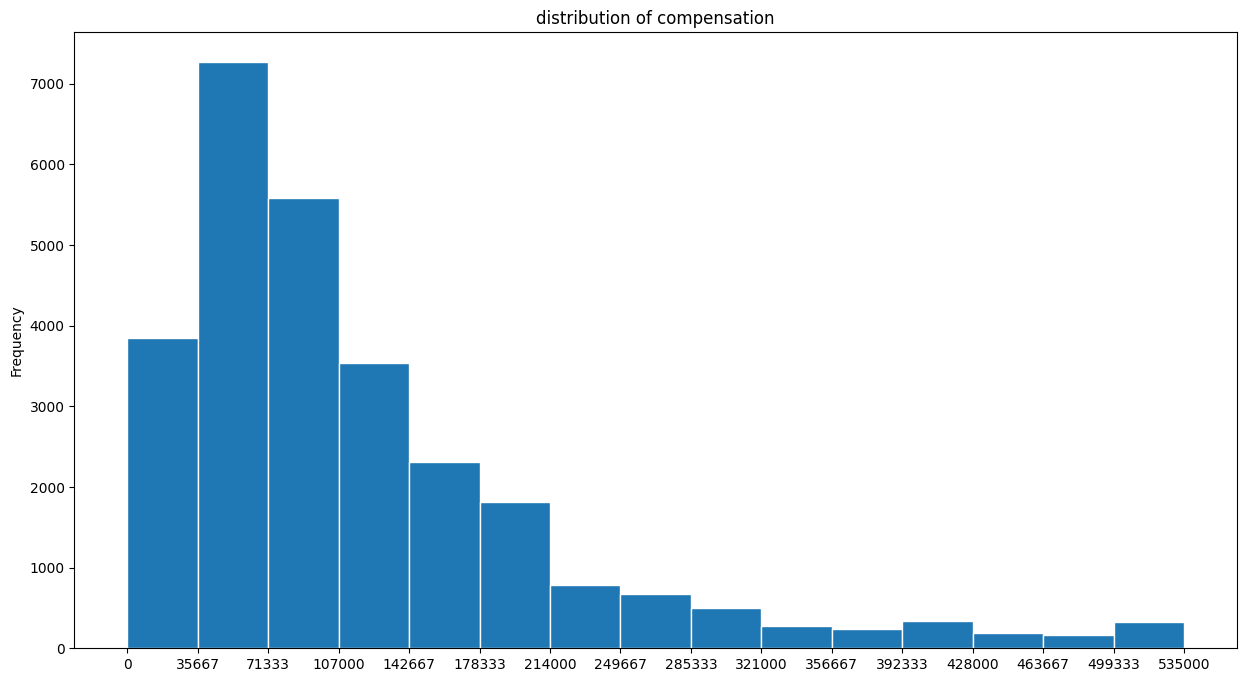

In [10]:
## Write your code here

CompTotal=pd.read_sql_query('Select CompTotal from main where CompTotal>0', conn)

Q1=np.quantile(CompTotal['CompTotal'], 0.25)
Q3=np.quantile(CompTotal['CompTotal'], 0.75)
IQR=Q3-Q1


cleanCompTotal=pd.read_sql_query(f'Select CompTotal from main where CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}', conn) # Extreme compensation values were removed using the IQR method to improve the readability of the histogram and prevent the distribution from being dominated by extreme outliers.
                                                                                                                            # More about Compensation data in DataWrangling/09_ImputMissing_Values
entries_in_bin, bin_range=np.histogram(cleanCompTotal['CompTotal'],15)

cleanCompTotal['CompTotal'].plot(kind='hist', figsize=(15,8), xticks=bin_range, bins=15, linewidth=1, edgecolor='white')
plt.title('distribution of compensation')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


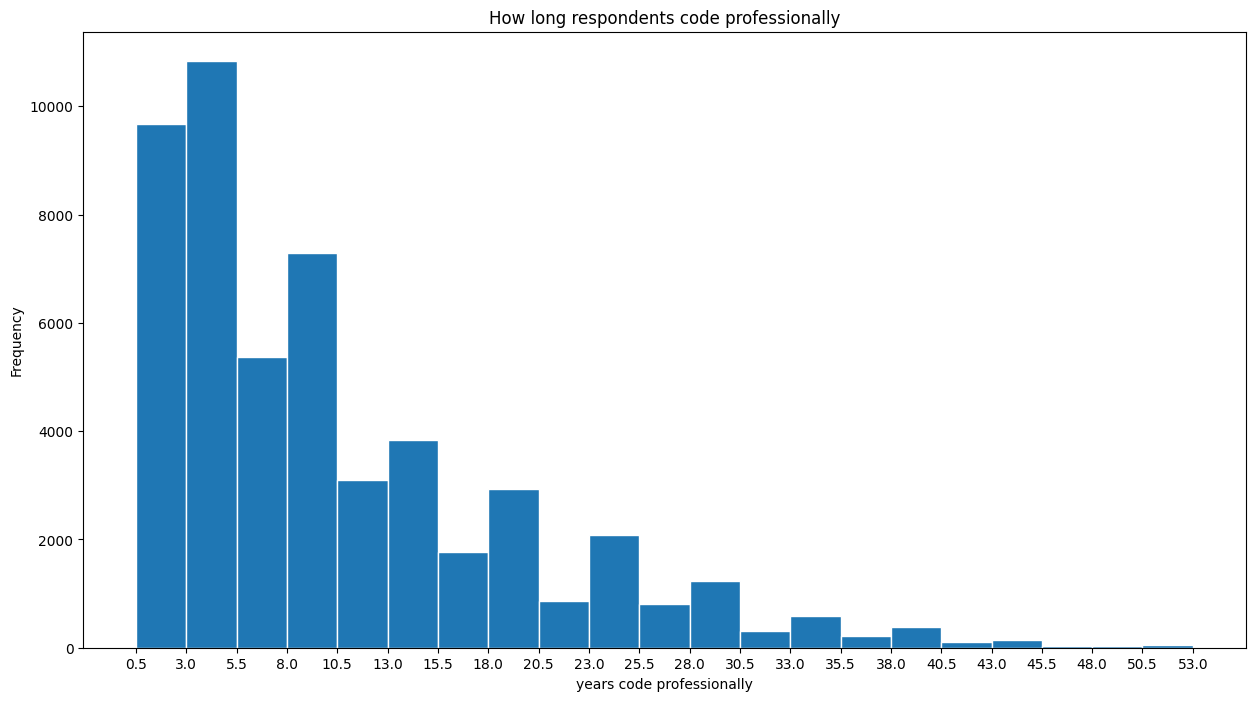

In [11]:
## Write your code here

years_code_pro=pd.read_sql_query('Select YearsCodePro from main Where YearsCodePro is not null', conn)

ycp=years_code_pro['YearsCodePro']

ycp=ycp.replace({                 # Convert categorical edge values into approximate numeric representations
    'Less than 1 year': 0.5
    ,'More than 50 years': 53
})

ycp=pd.to_numeric(ycp, errors='coerce')
ycp=ycp.dropna()

nr_of_entries, bin_range1= np.histogram(ycp,21)

ycp.plot(kind='hist'
         ,figsize=(15,8)
         ,xticks=bin_range1
         ,bins=21
         ,linewidth=1
         ,edgecolor='white'
         ,title='How long respondents code professionally'
         ,xlabel='years code professionally')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


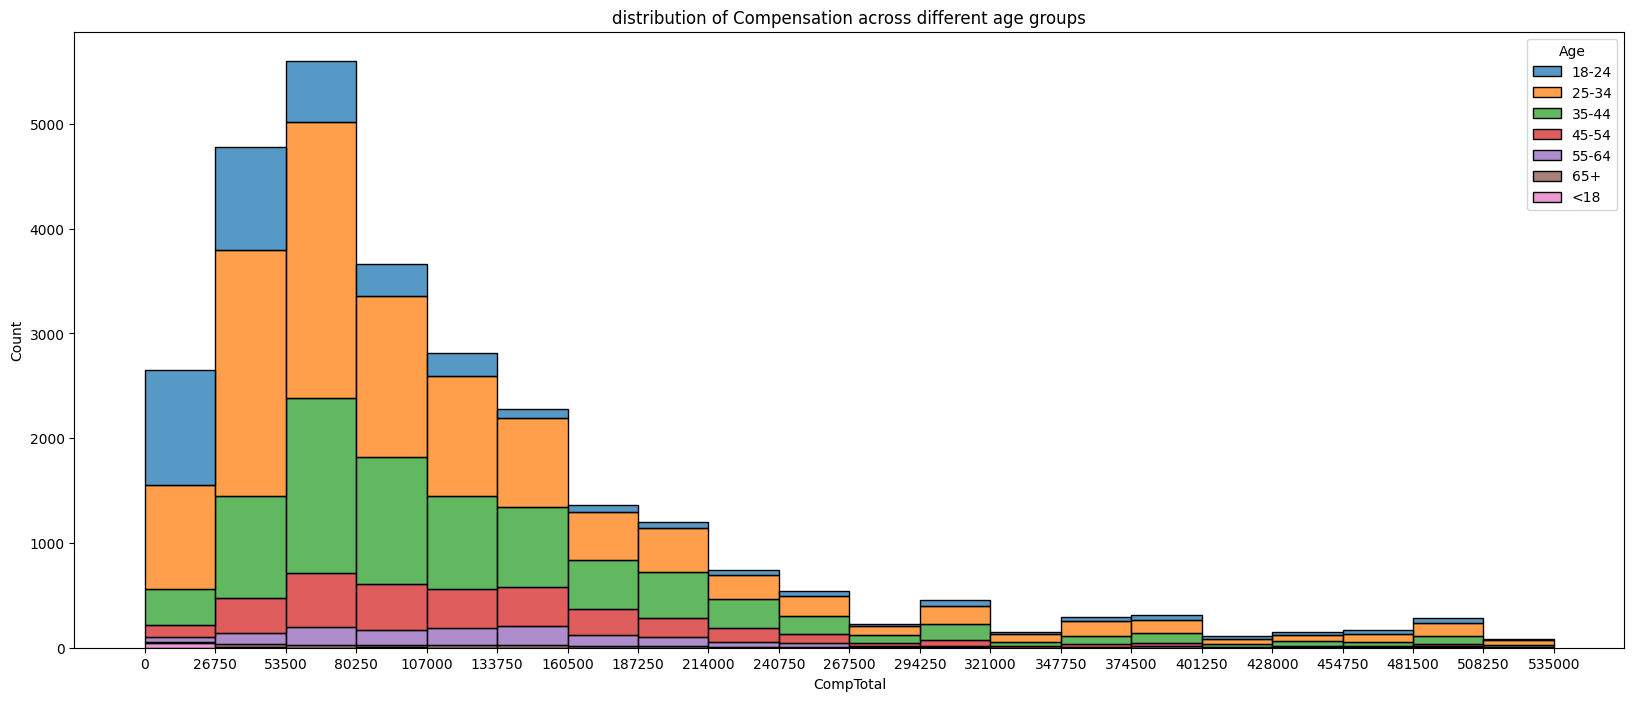

In [12]:
## Write your code here

age_comp=pd.read_sql_query(
    f''' Select Age, CompTotal
    from main
    where Age <> "Prefer not to say"
    and CompTotal is not null
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn) # Remove extreme compensation outliers using IQR method

age_comp['Age']=age_comp['Age'].replace({
    'Under 18 years old': '<18'
    ,'18-24 years old':'18-24'
    ,'25-34 years old':'25-34'
    ,'35-44 years old':'35-44'
    ,'45-54 years old':'45-54'
    ,'55-64 years old':'55-64'
    ,'65 years or older':'65+'
})

age_comp=age_comp.sort_values('Age')

bin_size, bin_range2= np.histogram(age_comp['CompTotal'],20)

plt.figure(figsize=(20,8))
sns.histplot(age_comp, x='CompTotal', hue='Age', multiple='stack',bins=20)
plt.title('distribution of Compensation across different age groups')
plt.xticks(bin_range2)
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


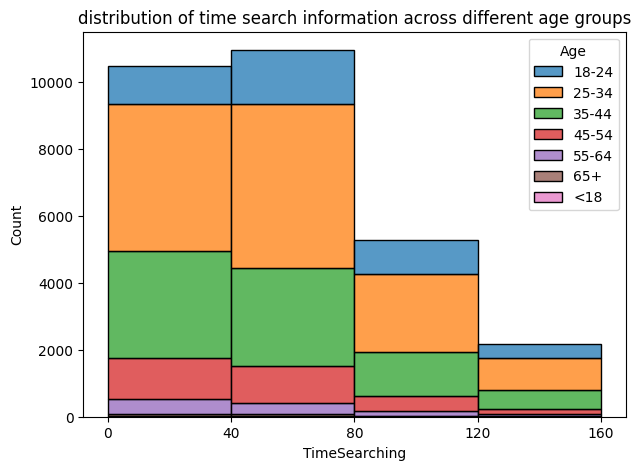

In [13]:
## Write your code here

age_search=pd.read_sql_query(
    ''' Select Age, TimeSearching
    from main
    where Age <> "Prefer not to say"
    and TimeSearching is not null''', conn)

age_search['Age']=age_search['Age'].replace({
    'Under 18 years old': '<18'
    ,'18-24 years old':'18-24'
    ,'25-34 years old':'25-34'
    ,'35-44 years old':'35-44'
    ,'45-54 years old':'45-54'
    ,'55-64 years old':'55-64'
    ,'65 years or older':'65+'
})

age_search['TimeSearching']=age_search['TimeSearching'].replace({
    'Less than 15 minutes a day':0
    ,'15-30 minutes a day':22.5
    ,'30-60 minutes a day':45
    ,'60-120 minutes a day':90
    ,'Over 120 minutes a day':160
})

age_search['TimeSearching']=pd.to_numeric(age_search['TimeSearching'], errors='coerce')
age_search = age_search.dropna(axis=0)

age_search=age_search.sort_values('Age')

bin_size, bin_range3= np.histogram(age_search['TimeSearching'],4)

plt.figure(figsize=(7,5))
sns.histplot(age_search, x='TimeSearching', hue='Age', multiple='stack',bins=4)
plt.title('distribution of time search information across different age groups')
plt.xticks(bin_range3)
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Bar chart of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a Bar chart of the top 5 databases.


In [14]:
## Write your code here

data_bases=pd.read_sql_query(
    ''' Select DatabaseWantToWorkWith 
        from main
        where DatabaseWantToWorkWith is not null''', conn
)

data_bases=data_bases['DatabaseWantToWorkWith']

data_bases=data_bases.str.split(';')
bases_counted=data_bases.explode().value_counts()                     # DatabaseWantToWorkWith is a multi-select question, split and explode allow analyzing each selected database type separately
top5_bases=bases_counted.iloc[0:5]
top5_bases

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

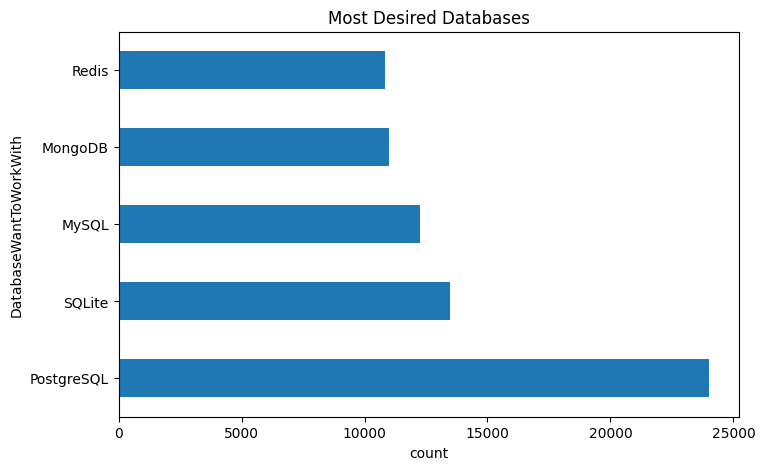

In [15]:
top5_bases.plot(kind='barh', figsize=(8,5), title='Most Desired Databases', xlabel='count')
plt.show()

**3.2 Bar chart of Preferred Work Locations (`RemoteWork`)**


Objective: Use a Bar chart to explore the distribution of preferred work arrangements (`remote work`).


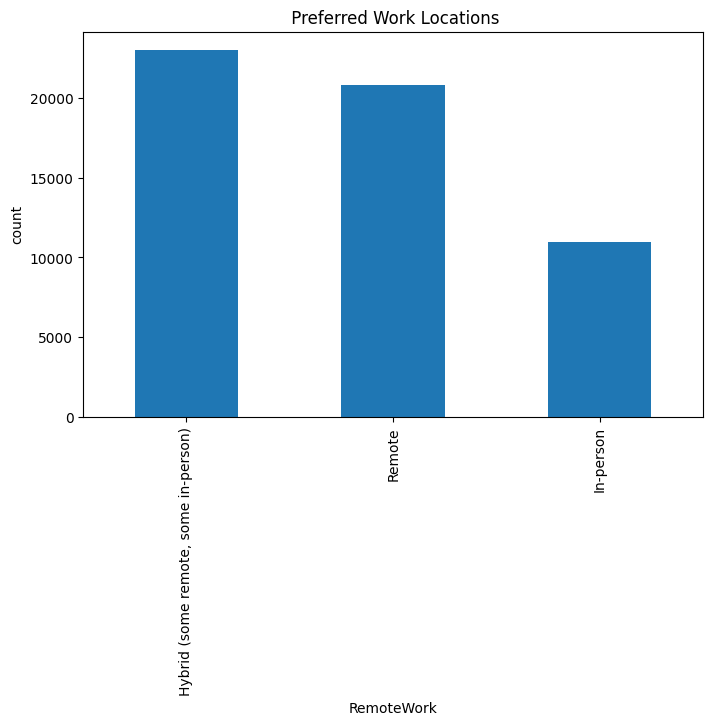

In [16]:
## Write your code here

remote_work=pd.read_sql_query(
    '''select RemoteWork from main where RemoteWork is not null''', conn)

remote_work_counted=remote_work['RemoteWork'].value_counts()

remote_work_counted.plot(kind='bar', figsize=(8,5), title=' Preferred Work Locations', ylabel='count')
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 64**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 64 to analyze compensation distribution among mid-career respondents.


In [17]:
## Write your code here

age_comp=pd.read_sql_query(
    f''' Select Age, CompTotal
    from main 
    where Age in ("45-54 years old", "55-64 years old")
    and CompTotal between {Q1-1.5*IQR} and {Q3+1.5*IQR}''', conn)  # Remove outliers using IQR method calculated on the full compensation distribution


print('table shape', age_comp.shape)
median_comp=age_comp.groupby('Age').median()
median_comp

table shape (4168, 2)


,CompTotal
Age,
45-54 years old,115000.0
55-64 years old,124110.0


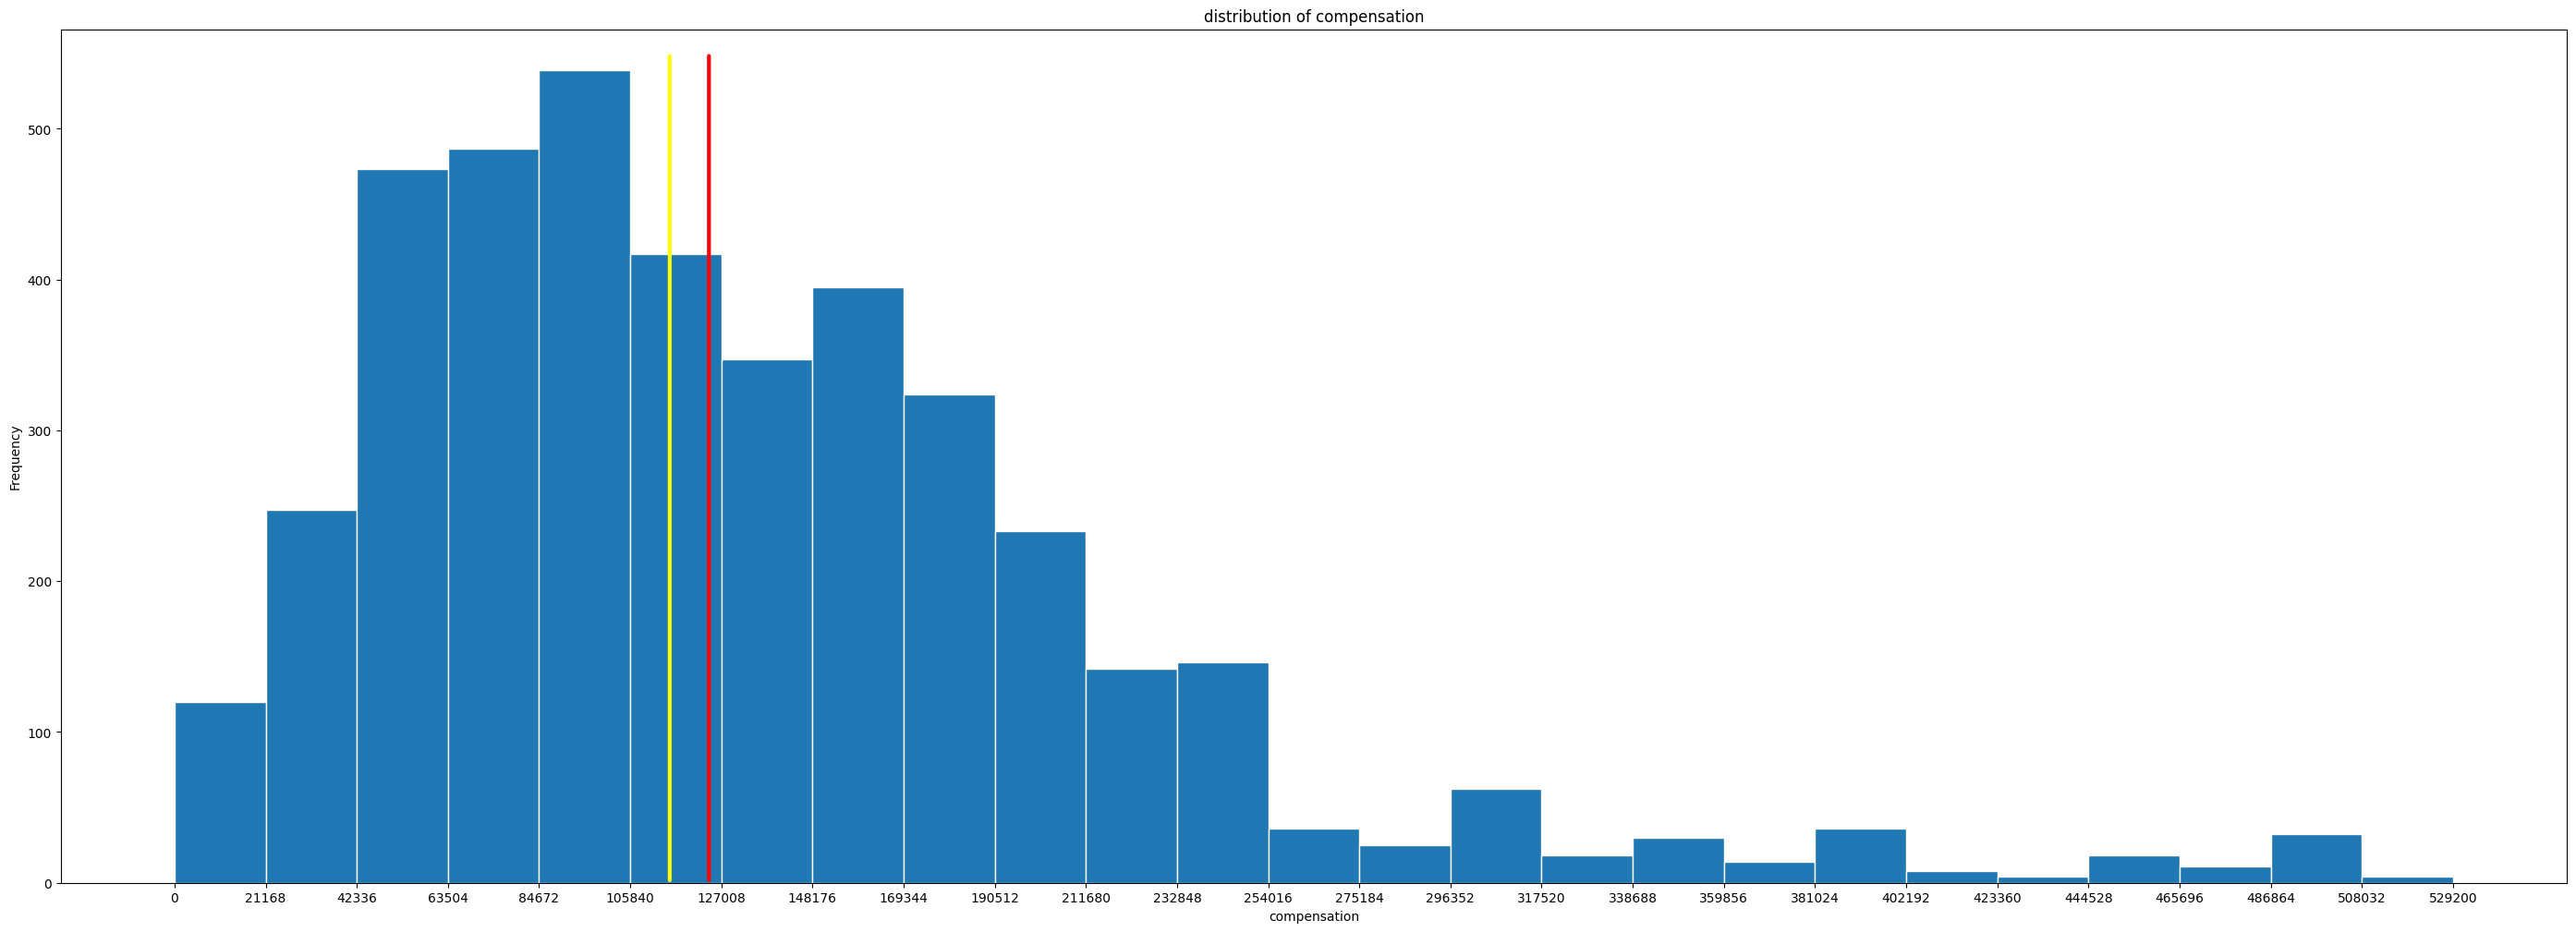

In [18]:
entries_in_bin, bin_range4=np.histogram(age_comp['CompTotal'],25)

age_comp['CompTotal'].plot(kind='hist'
                           ,figsize=(35,12)
                           ,xticks=bin_range4
                           ,bins=25
                           ,linewidth=1
                           ,edgecolor='white'
                           ,title='distribution of compensation'
                           ,xlabel='compensation'
)
plt.annotate(''
             ,xy=(median_comp.iloc[0,0],0)
             ,xytext=(median_comp.iloc[0,0],550)
             ,xycoords='data'
             ,arrowprops=dict(
                 arrowstyle='-'
                 ,connectionstyle='arc3,rad=0'
                 ,color='yellow'
                 ,lw=3
                 )
            )
plt.annotate(''
             ,xy=(median_comp.iloc[1,0],0)
             ,xytext=(median_comp.iloc[1,0],550)
             ,xycoords='data'
             ,arrowprops=dict(
                 arrowstyle='-'
                 ,connectionstyle='arc3,rad=0'
                 ,color='red'
                 ,lw=3
                 )
            )

plt.show()

**The yellow line is the median compensation for the 45–54 age group, while the red one is for the 55–64 group**

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


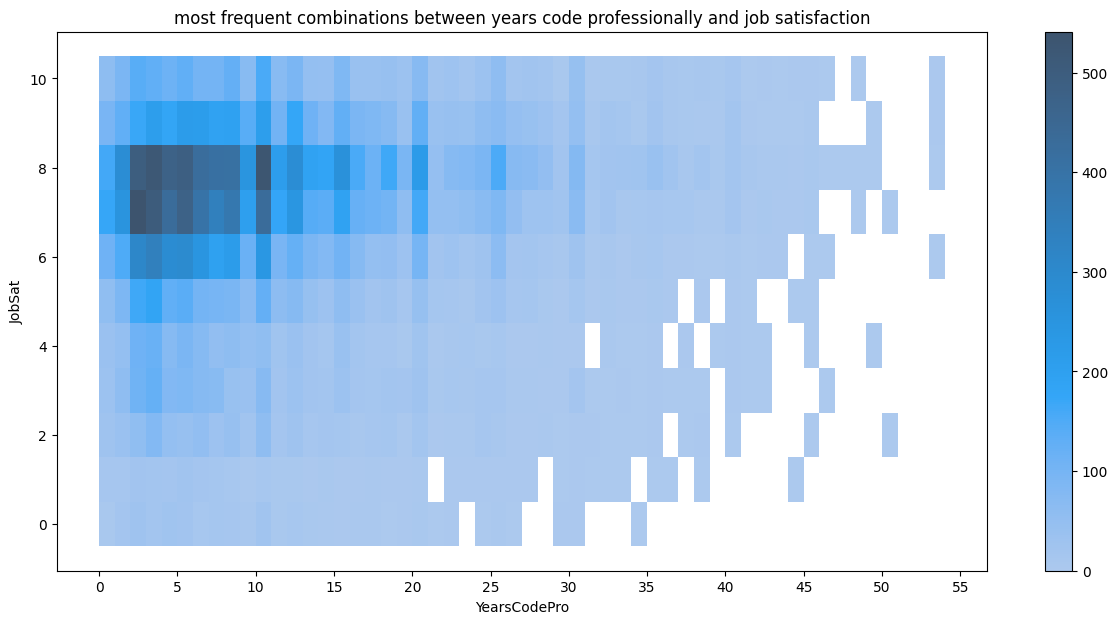

In [19]:
## Write your code here

code_sat=pd.read_sql_query(
    '''Select YearsCodePro, JobSat 
    from main 
    Where YearsCodePro is not null
    and JobSat is not null''', conn)

code_sat['YearsCodePro']=code_sat['YearsCodePro'].replace({
    'Less than 1 year': 0.5
    ,'More than 50 years': 53
})

code_sat['YearsCodePro']=pd.to_numeric(code_sat['YearsCodePro'], errors='coerce')
code_sat=code_sat.dropna()

plt.figure(figsize=(15,7))
sns.histplot(code_sat, x='YearsCodePro', y='JobSat', cbar=True, discrete=True)
plt.title('most frequent combinations between years code professionally and job satisfaction')
plt.xticks(np.linspace(0,55,12))
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [20]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
